### CC-PULPO Case Study: Ammonia Production
This notebook showcases the application of CC-PULPO and the broader uncertainty framework to an ammonia production case study. Here, two epistemic uncertainty iterations are presented.

In [1]:
# Enable automatic reloading of modified modules
%load_ext autoreload
%autoreload 2

# Import helpers to keep main script clean
import notebook_utils.a0_uncertainty_utils as unc_utils
import notebook_utils.a0_uncertainty_plots as unc_plots

import bw2data as bd
import bw2io as bi
from bw2io.package import BW2Package

from pulpo import pulpo 
from pulpo.utils.uncertainty import processor
import numpy as np
import pandas as pd
from copy import deepcopy

from SALib.sample import sobol as sample_method
from SALib.analyze import sobol as SA_method

#### LCI Implementation
First, create a project and import the **ecoinvent 3.10 (cutoff)** background LCI. Set your ecoinvent credentials as environment variables (_Windows: run Command Prompt as Administrator_):

```
setx ECOINVENT_USERNAME "your_username"
setx ECOINVENT_PASSWORD "your_password"
```

*Restart VS Code or your machine after setting these variables.*

In [2]:
PROJECT = "ammonia_last"
EI_NAME = "ecoinvent-3.10-cutoff"

#username = "your_username"  # Replace with actual username
#password = "your_password"  # Replace with actual password

# 1) Ensure project exists / is selected
bd.projects.set_current(PROJECT)

# 2) Import ecoinvent 3.10 cutoff if missing
if EI_NAME in bd.databases:
    print(f"Database '{EI_NAME}' already exists in project '{bd.projects.current}'.")
else:
    username, password = unc_utils.get_ecoinvent_credentials()
    bi.import_ecoinvent_release(
        version="3.10",
        system_model="cutoff",
        username=username,
        password=password,
    )
    print(f"Database '{EI_NAME}' installed successfully.")

Database 'ecoinvent-3.10-cutoff' already exists in project 'ammonia_last'.


Next, import the **ammonia foreground LCI** from the Excel spreadsheet.

In [3]:
# Path to your Excel file
excel_path = r"data/ammonia.xlsx"
FG_NAME = "ammonia"

if FG_NAME in bd.databases:
    print(f"Database '{FG_NAME}' already exists in project '{bd.projects.current}'.")
else:
    fg_db = bi.ExcelImporter(excel_path)
    fg_db.apply_strategies()
    fg_db.match_database(fields=["name", "unit", "reference product", "location"])
    fg_db.match_database("ecoinvent-3.10-cutoff", fields=["name", "unit", "location", "reference product"])
    biosphere_db = [db for db in bd.databases if "biosphere" in db and "3.10" in db][0]
    fg_db.match_database(biosphere_db, fields=["name", "categories", "location"])
    fg_db.statistics()
    fg_db.write_database()
    print(f"Database '{FG_NAME}' installed successfully.")

Database 'ammonia' already exists in project 'ammonia_last'.


#### LCIA Implementation (GWP Uncertainty)

This method has been obtained and adapted (introduction of -1 for biogenic carbon) from [Github](https://github.com/aleksandra-kim/gwp_uncertainties)

In [4]:
METHOD = ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
bd.projects.set_current(PROJECT)

if METHOD in bd.methods:
    print(f"Method '{METHOD}' already exists in the project.")
else:
    BW2Package.import_file("data/ipcc_uncertain.bw2package")
    print("IPCC 2013 GWP with uncertainty characterization factors added successfully.")

Method '('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')' already exists in the project.


### Case Study Definition

First, define some helper functions and specify missing project parameters.

In [5]:
# PROJECT; EI_NAME; FG_NAME; METHOD - Are all previously defined!
METHOD = str(METHOD)
DATABASES = [EI_NAME, FG_NAME]
DIRECTORY = "data/results"

def create_pulpo_worker(project, database, method, directory):
    """
    Create and initialize a PULPO optimizer instance.
    Returns: pulpo.PulpoOptimizer: Configured PULPO worker instance
    """
    # Create PulpoOptimizer instance
    pulpo_worker = pulpo.PulpoOptimizer(project, database, method, directory)
    pulpo_worker.intervention_matrix = "ecoinvent-3.10-biosphere"
    
    # Import LCI data
    pulpo_worker.get_lci_data()
    return pulpo_worker

def get_single_process(worker, query, prefer_locations=("RER", "Europe", "GLO")):
    """Deterministic process retrieval to avoid order issues."""
    matches = worker.retrieve_processes(processes=query)
    if not matches:
        raise ValueError(f"No process found for query: {query}")
    # Try preferred locations first
    for loc in prefer_locations:
        for p in matches:
            if getattr(p, "location", None) == loc or loc in str(p):
                return p
    return sorted(matches, key=lambda x: str(x))[0]

Then, define the case study by specifying **demand**, **choices**, and **constraints**.

In [6]:
def define_ammonia_problem(pulpo_worker):
    """
    Define the ammonia production optimization problem with streamlined configuration.
    """
    # Choice definitions with capacities bound per-label
    choice_config = {
        "biogas": {
            "processes": [
                "anaerobic digestion of agricultural residues",
                "anaerobic digestion of sequential crop",
                "anaerobic digestion of animal manure",
            ],
            # 2030 EU-27 potentials from biomethane shares (38 bcm total; 24% ag, 21% sequential, 32% manure),
            # converted to raw biogas assuming ~57% CH₄ → 16.0 & 14.0 bcm & 21.3 bcm ≈ 1.60e10 & 1.40e10 & 2.13e10 m³/yr.
            "capacities": [1.60e10, 1.40e10, 2.13e10],
        },
        "biomethane": {
            "processes": [
                "upgrading water scrubbing (CCS)",
                "upgrading water scrubbing",
                "upgrading chemical scrubbing",
                "upgrading chemical scrubbing (CCS)",
            ],
            "capacities": [1e20, 1e20, 1e20, 1e20],
        },
        "methane": {
            "processes": ["market for methane fg", "market for biomethane"],
            "capacities": [1e20, 1e20],
        },
        "heat": {
            "processes": ["heat from methane", "heat from methane (CCS)", "heat from hydrogen"],
            "capacities": [1e20, 1e20, 1e20],
        },
        "hydrogen": {
            "processes": [
                "methane pyrolysis",
                "steam methane reforming",
                "steam methane reforming (CCS)",
                "plastics gasification",
                "plastics gasification (CCS)",
                "alkaline electrolysis",
                "PEM electrolysis",
            ],
            # Methane pyrolysis capped to 10,000 t H2/yr (= 1.0e7 kg/yr); others left high for now.
            # "capacities": [3.0e8, 1e20, 1e20, 1e20, 1e20, 1e20, 1e20],
            "capacities": [1e20, 1e20, 1e20, 1e20, 1e20, 1e20, 1e20],
        },
        "ammonia": {
            "processes": [
                "steam reforming, integrated",
                "steam reforming, integrated (CCS)",
                "nitrogen + hydrogen",
            ],
            "capacities": [1e20, 1e20, 1e20],
        },
    }

    # Build choices with deterministic mapping
    choices = {}
    for category, cfg in choice_config.items():
        labels, caps = cfg["processes"], cfg["capacities"]
        if len(labels) != len(caps):
            raise ValueError(f"Length mismatch in '{category}': {len(labels)} labels vs {len(caps)} capacities")
        choices[category] = {get_single_process(pulpo_worker, lbl): cap for lbl, cap in zip(labels, caps)}

    # Demand (EU ammonia, kg/yr)
    demand_process = get_single_process(pulpo_worker, "market for ammonia")
    demand = {demand_process: 17.1e9}  # ~17.1 Mt/yr (EU)

    # Additional upper bounds (shared resources / feedstocks)
    waste_pp = get_single_process(pulpo_worker, "treatment of waste PP")
    waste_ps = get_single_process(pulpo_worker, "treatment of waste PS")
    ccs_process = get_single_process(pulpo_worker, "CCS 200km pipeline 1000m deep")

    upper_bounds = {
        waste_pp: 1e20,     #1.875e9,  # 25% of ~7.5 Mt PP post-consumer waste ≈ 1.875 Mt/yr
        waste_ps: 1e20,     #3.25e8,   # 25% of ~1.3 Mt PS waste ≈ 0.325 Mt/yr
        ccs_process: 1e20,  #5.0e9,    # 5 MtCO2/yr (10% of EU-27 2030 NZIA target)
    }
    
    # Instantiate the optimization problem
    pulpo_worker.instantiate(demand=demand, choices=choices, upper_limit=upper_bounds)
    
    return choices, demand

def solve_and_summarize(pulpo_worker, file_name='ammonia_results'):
    # Solve optimization problem
    pulpo_worker.solve(solver_name="gurobi")
    
    # Extract and summarize results
    result_data = pulpo_worker.extract_results()
    pulpo_worker.summarize_results(zeroes=True)
    
    return result_data

Solve the base case, without consideration of any uncertainties.

In [8]:
# Create and initialize PULPO worker
print("1. Creating PULPO worker...")
pulpo_worker = create_pulpo_worker(PROJECT, DATABASES, METHOD, DIRECTORY)

# Define the optimization problem
print("2. Defining optimization problem...")
choices, demand = define_ammonia_problem(pulpo_worker)

# Solve the problem and get results
print("3. Solving optimization problem...")
result_data = solve_and_summarize(pulpo_worker, file_name='ammonia_test')

print(f"✅ Setup complete: {sum(len(c) for c in choices.values())} alternatives across {len(choices)} categories")

1. Creating PULPO worker...
2. Defining optimization problem...
Creating Instance
Instance created
3. Solving optimization problem...
Optimization problem solved using gurobi
status=ok, termination=optimal


## Total Impact(s)

,Weight,Value
Method,,
"('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')",1,-2.817763e+10


## Choices Made

### biogas

...

,Value,Capacity
Metadata,,
"steam reforming, integrated (CCS) | ammonia | RER",1.710000e+10,1.000000e+20


## Constraints

### Constraints Upper

,Key,Metadata,Value,Limit
ID,,,,
23523,"(ammonia, fc378c5b9e61e417e77ba0c166897da5_copy1)",CCS 200km pipeline 1000m deep | CO2 stored | RER,6.925536e+10,1.000000e+20


✅ Setup complete: 22 alternatives across 6 categories


### Ieration 0: Generic Uncertainty Treatment

In this iteration, no technology or availablity constraints are considered except for availability of waste feedstock. In a first step, the uncetainty data of the LCIs and LCIA method are analysed in order to proceed with the gap filling strategies.

In [9]:
pulpo_worker.import_and_filter_uncertainty_data(
    cutoff=0.,
    scaling_vector_strategy='constructed_demand',
    plot_results=False,
    plot_n_top_processes=19,
)

chosen environmental impact method: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
The total impact is: 4.475472e+01
Characterized inventory: (2648, 23569) 21677
Filtered characterized inventory: (2648, 23569) 21677
Deviation from LCA score: 0.0
inventory (2648, 23569) filtering resulted in 21677 of 21677 exchanges (100.0% of total impact) and took 0.006 seconds.
CHARACTERIZATION MATRIX (2648,) filtering resulted in 82 of 91 characterization factors
Intervention flows:
In ecoinvent-3.10-cutoff:
Parameters with uncertainty information: 16110 
Parameters without uncertainty information: 5510
In ammonia:
Parameters with uncertainty information: 0 
Parameters without uncertainty information: 57
Charactetization factors:
Parameters with uncertainty information: 31 
Parameters without uncertainty information: 51
Variable bounds:
Upper bound from choices without uncertainty information: 22
Upper bound from `upper_limit` without uncertainty information: 3
Low

Uncertainty gaps are filled using triangular distributions based on statistical analysis of existing uncertainties. Background data uses interpolated bounds, foreground inventories use scaling factors (0.5-1.95 ... obtained from ecoinvent) with upward skew, and random noise adds artificial variance. Characterization factors use only existing uncertainties without gap filling.

In [10]:
unc_strategies = [
    processor.TriangularBoundInterpolationStrategy(
        uncertain_param_type='If',
        uncertain_param_subgroup='ecoinvent-3.10-cutoff',
        noise_interval={'min':.1, 'max':.1}
    ),
    processor.TriangluarBaseStrategy( # Assuming that the Foreground uncertainties are similar to the background ones
        uncertain_param_type='If',
        uncertain_param_subgroup='ammonia',
        upper_scaling_factor = 0.95, # The same as from TriangularBoundInterpolationStrategy of EcoInvent
        lower_scaling_factor = .5, # The same as from TriangularBoundInterpolationStrategy of EcoInvent
        noise_interval={'min':.1, 'max':.1}
    ),
    # This is set to very low scaling factors to reflect that we assume only off-the-shelf uncertainty in CFs based on literature
    processor.TriangluarBaseStrategy( # Based on Chen et al. 2021 10-20% variation in CFs
    uncertain_param_type='Cf',
    uncertain_param_subgroup=METHOD,
    upper_scaling_factor = 0.0001,
    lower_scaling_factor = 0.0001,
    noise_interval={'min':.00, 'max':.00},
    inverse_bounds_for_negative_values = False # This means that the skew is always towards zero, indepent if value is larger or smaller to zero
    )
    ]


In [11]:
pulpo_worker.apply_uncertainty_strategies(strategies=unc_strategies, plot_results=False)

Applying uncertainy strategy TriangularBoundInterpolationStrategy, for ecoinvent-3.10-cutoff in If
Computed spread statistics for 16110 uncertain parameters with defined uncertainty bounds.
upper spread statistics
geom: 0.4531 
mean: 1.8945
mode: 0    3.466758
Name: upper spread, dtype: float64
median: 0.9177
std: 8.2191
min: 0.0287
max: 786.9859


lower spread statistics
geom: 0.4531 
mean: 0.6215
mode: 0    0.776124
Name: lower spread, dtype: float64
median: 0.4786
std: 7.9779
min: 0.0279
max: 786.9859

After cleaning out outliers (z-score > 3), the spread statistics are:
upper spread statistics
geom: 0.4524 
mean: 1.7772
mode: 0    3.466758
Name: upper spread, dtype: float64
median: 0.9177
std: 1.8876
min: 0.0287
max: 24.2562


lower spread statistics
geom: 0.4524 
mean: 0.5146
mode: 0    0.776124
Name: lower spread, dtype: float64
median: 0.4786
std: 0.2953
min: 0.0279
max: 19.7686

The upper spread scaling factor for intervention flows is: 0.9177497397592225
The lower spread scali

Solve the multi-objective optimization problem using epsilon-constrained method on the lambda parameter.

In [12]:
normal_metadata_env_cost, normal_metadata_var_bounds = pulpo_worker.create_CC_formulation(CC_env_cost=True)

No uncertainty data missing.
No uncertainty data missing.
Transforming If-ecoinvent-3.10-cutoff to normal distribution
21607 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
Transforming If-ammonia to normal distribution
57 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
Transforming Cf-('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain') to normal distribution
59 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation


Visualize results

In [13]:
# Define abbreviations for legend entries visible in the plot
abbreviations = {
    # Biogas technologies
    "anaerobic digestion of animal manure | biogas | RER": "AD-Manure",
    "anaerobic digestion of agricultural residues | biogas | RER": "AD-Agri",
    "anaerobic digestion of sequential crop | biogas | RER": "AD-SeqCrop",
    
    # Biomethane upgrading
    "upgrading chemical scrubbing (CCS) | biomethane, 24 bar | RER": "Chem. Scrubbing+CCS",
    
    # Methane sources
    "market for biomethane | biomethane, 24 bar | RER": "Biomethane",
    
    # Heat sources
    "heat from hydrogen | heat | RER": "H₂ Heat",
    "heat from methane (CCS) | heat | RER": "CH₄ Heat+CCS",
    
    # Hydrogen production
    "steam methane reforming (CCS) | hydrogen | RER": "SMR+CCS",
    "plastics gasification (CCS) | hydrogen | RER": "Plastics gasif. (CCS)",
    
    # Ammonia production
    "steam reforming, integrated (CCS) | ammonia | RER": "SMR (Integrated)+CCS",
    "nitrogen + hydrogen | ammonia | RER": "N₂ + H₂",

    # Other
    "CCS 200km pipeline 1000m deep | CO2 stored | RER": "CCS pipeline",
}

### Iteration 1: Biomass Expert Judgement

**Analysis Outcome & Motivation**
Initial analysis of the Pareto front reveals that negative impacts are overwhelmingly driven (>90%) by carbon content in sequential crops and manure. The system shows extreme sensitivity to these feedstock variables, favoring a technological pathway of **Biogas to Biomethane and SMR with CCS**. Consequently, the feasibility of this pathway hinges on the availability and modeling of biomass, which is currently treated with deterministic optimism.

**Addressing Epistemic Uncertainty**
To address this sensitivity, this iteration integrates epistemic uncertainty factors that challenge the stability of the biomass supply chain and its environmental accounting.

**1. Re-evaluating Biomass CO₂ Uptake (The Carbon Balance)**
Current models assume a perfect carbon balance where all field-captured CO₂ reaches the anaerobic digestion plant. We introduce uncertainty regarding:
* **Systemic Feedback:** The loss of soil carbon sequestration (humus formation) and nutrient retention when residues are removed rather than tilled.
* **Allocation Risks:** The potential for waste products (manure) to become economic drivers, locking in intensive, environmentally destructive farming practices.
* **Modeling Adjustment:** We inverse the probability distribution for CO₂ uptake. The upper bound is constrained to reflect losses during transport and the substitution cost of lost soil sequestration, pushing the realistic uptake closer to zero.

Identify and extract metadata for CO₂ uptake intervention flows from anaerobic digestion processes to analyze epistemic uncertainty factors.

In [14]:
# Gets the descriptive names of the intervention flows for ammonia related processes
If_ammonia_unc = processor.rename_metadata_index(
    pd.DataFrame.from_records(pulpo_worker.uncertainty_data['If']['ammonia']['defined']).T, 
    pulpo_worker.lci_data, 
    'intervention_flow'
    )

# The intervention flows which might require special attention
If_names = [
    "anaerobic digestion of agricultural residues | biogas | RER --- Carbon dioxide, in air | ('natural resource', 'in air')",
    "anaerobic digestion of animal manure | biogas | RER --- Carbon dioxide, in air | ('natural resource', 'in air')",
    "anaerobic digestion of sequential crop | biogas | RER --- Carbon dioxide, in air | ('natural resource', 'in air')"
]

# Plotting the distributions of the selected intervention flows
matched_If_indcs = If_ammonia_unc.loc[If_names, 'index'].values
matched_If_unc_metadata = {indx:pulpo_worker.uncertainty_data['If']['ammonia']['defined'][indx] for indx in matched_If_indcs}
processor.fit_normals(matched_If_unc_metadata, plot_distributions=False, lci_data=pulpo_worker.lci_data)


3 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation


{(81, 23528): {'scale': 0.6969107173401683,
  'loc': 2.7913368554168634,
  'uncertainty_type': 3},
 (81, 23529): {'scale': 0.6998148718135181,
  'loc': 2.792937079712335,
  'uncertainty_type': 3},
 (81, 23530): {'scale': 0.7483404334952996,
  'loc': 2.816864940268381,
  'uncertainty_type': 3}}

Reverse probability distribution for CO₂ uptake to account for soil carbon loss and transport inefficiencies.

In [15]:
lower_scaling_factor = .5 #.9
upper_scaling_factor = .1
for indx, unc_metadata in matched_If_unc_metadata.items():
    matched_If_unc_metadata[indx]['minimum'] = unc_metadata['amount'] - unc_metadata['amount'] * lower_scaling_factor
    matched_If_unc_metadata[indx]['maximum'] = unc_metadata['amount'] + unc_metadata['amount'] * upper_scaling_factor
processor.fit_normals(matched_If_unc_metadata, plot_distributions=False, lci_data=pulpo_worker.lci_data)


3 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation


{(81, 23528): {'scale': 0.3206054007925747,
  'loc': 2.1190912611229575,
  'uncertainty_type': 3},
 (81, 23529): {'scale': 0.3206236609186155,
  'loc': 2.1186443611526498,
  'uncertainty_type': 3},
 (81, 23530): {'scale': 0.32085168863768615,
  'loc': 2.1182994419129706,
  'uncertainty_type': 3}}

Implement epistemic uncertainty adjustments for biomass CO₂ uptake using expert knowledge strategy.

In [16]:
epistemic_unc_strategies_iteration_1 = [processor.ExpertKnowledgeStrategy(
        uncertain_param_type='If',
        uncertain_param_subgroup='ammonia',
        prob_metadata=matched_If_unc_metadata
    )]
pulpo_worker.apply_uncertainty_strategies(strategies=epistemic_unc_strategies_iteration_1)

Applying uncertainy strategy ExpertKnowledgeStrategy, for ammonia in If
Var_bounds - upper_limit 
 	 25 parameters without uncertainty information


Generate chance-constrained formulation incorporating both environmental cost and variable bounds uncertainties.

In [18]:
normal_metadata_env_cost, normal_metadata_var_bounds = pulpo_worker.create_CC_formulation(CC_env_cost=True)

No uncertainty data missing.
No uncertainty data missing.
Transforming If-ecoinvent-3.10-cutoff to normal distribution
21607 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
Transforming If-ammonia to normal distribution
57 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
Transforming Cf-('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain') to normal distribution
59 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation


#### Solve CC problem with epistemic uncertainties

Solve the chance-constrained optimization problem for lambda values from 0.5 to 0.9 with 0.1 increments to analyze the impact of epistemic uncertainty adjustments.

In [19]:
lambda_epsilon_array_it1 = np.concatenate([np.arange(0.5, 0.95, 0.04), np.arange(0.95, 0.99, 0.01)])
results_CC_it1 = pulpo_worker.solve_CC_problem(lambda_epsilon_array_it1, normal_metadata_env_cost, normal_metadata_var_bounds, plot_results=False)

solving CC problem for lambda_QB = 0.5
Applying CC constraints to the environmental cost calculation with lambda: 0.5
optimal solution found:  -12733829370.007812
solving CC problem for lambda_QB = 0.54
Applying CC constraints to the environmental cost calculation with lambda: 0.54
optimal solution found:  -10687383715.816216
solving CC problem for lambda_QB = 0.5800000000000001
Applying CC constraints to the environmental cost calculation with lambda: 0.5800000000000001
optimal solution found:  -8620031422.551117
solving CC problem for lambda_QB = 0.6200000000000001
Applying CC constraints to the environmental cost calculation with lambda: 0.6200000000000001
optimal solution found:  -6509328789.1346035
solving CC problem for lambda_QB = 0.6600000000000001
Applying CC constraints to the environmental cost calculation with lambda: 0.6600000000000001
optimal solution found:  -4329447111.655035
solving CC problem for lambda_QB = 0.7000000000000002
Applying CC constraints to the environmen

#### Visualize epistemic uncertainty results

Generate Pareto front plot showing the impact of epistemic uncertainty adjustments on the trade-offs between cost and environmental performance.

In [20]:
# --- Planetary Boundary Downscaling: Global GWP to EU Ammonia ---
"""
Calculates the annual CO2e budget for European Ammonia production
based on Absolute Environmental Sustainability Assessment (AESA) principles.

Methodology:
1. Global -> Region: Equal Per Capita (Population Share)
2. Region -> Sector: Economic Value Added (GDP Share)
3. Sector -> Product: Revenue Share
"""

# --- 1. Global Safe Operating Space (SOS) ---
# Source: Sala et al. (2020)
# Unit: kg CO2e / year
sos_global = 6.81e12 

# --- 2. Regional Share (Europe) ---
# Principle: Equal Per Capita
# Data: Eurostat (EU) / World Bank (Global) - approx 2023 figures
pop_global = 8.0e9      # 8.0 Billion
pop_eu = 448.0e6        # 448 Million

share_region = pop_eu / pop_global

# --- 3. Sector Share (Chemical Industry) ---
# Principle: Economic Value Added (Contribution to GDP)
# Data: Cefic Facts & Figures 2023
gdp_eu = 17.0e12        # ~€17 Trillion
gva_chemical = 165.0e9  # ~€165 Billion

share_sector = gva_chemical / gdp_eu

# --- 4. Product Share (Ammonia) ---
# Principle: Revenue Share (Turnover)
# Data: Cefic / Market Reports (Est. 17Mt prod * €600/t)
turnover_chemical = 655.0e9   # ~€655 Billion
revenue_ammonia = 10.2e9      # ~€10.2 Billion

share_product = 1 # revenue_ammonia / turnover_chemical

# --- 5. Final Calculation ---
limit_eu_ammonia = sos_global * share_region * share_sector * share_product

# --- Output Results ---
print(f"{'--- Downscaling Factors ---':<30}")
print(f"{'Global SOS:':<20} {sos_global/1e9:.2f} Gt CO2e")
print(f"{'EU Pop Share:':<20} {share_region:.2%}")
print(f"{'Chem Sector Share:':<20} {share_sector:.2%}")
print(f"{'Ammonia Rev Share:':<20} {share_product:.2%}")
print("-" * 30)
print(f"{'Final Annual Budget:':<20} {limit_eu_ammonia/1e6:.2f} Million kg CO2e")
print(f"{'Final Annual Budget:':<20} {limit_eu_ammonia/1e9:.5f} Million tonnes CO2e")

--- Downscaling Factors ---   
Global SOS:          6810.00 Gt CO2e
EU Pop Share:        5.60%
Chem Sector Share:   0.97%
Ammonia Rev Share:   100.00%
------------------------------
Final Annual Budget: 3701.44 Million kg CO2e
Final Annual Budget: 3.70144 Million tonnes CO2e


In [21]:
### VALUE FROM BARTO ###
limit_eu_ammonia = 6e9

Generating Pareto front plot with epistemic uncertainty adjustments...


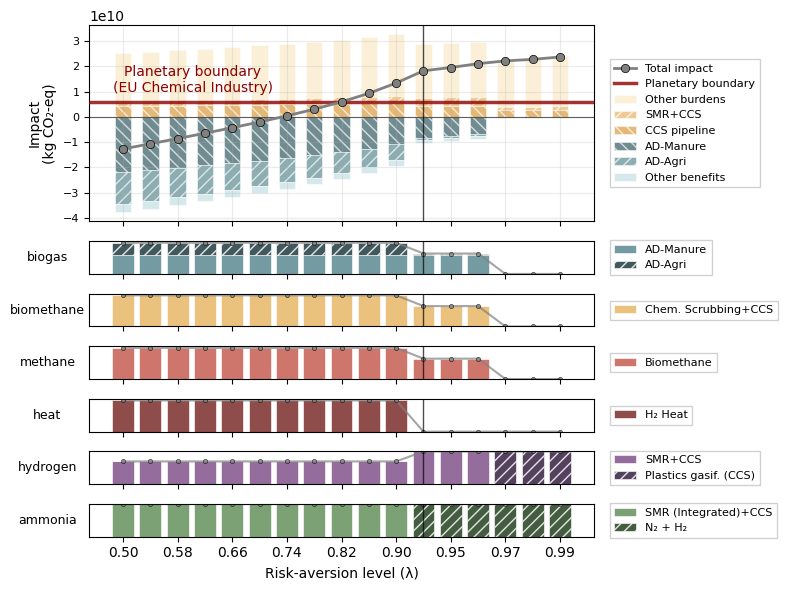

Epistemic uncertainty Pareto plot saved to: {'png': 'data/results\\pareto_and_choices_combined_it1.png', 'svg': 'data/results\\pareto_and_choices_combined_it1.svg'}


In [ ]:
# Plot Pareto front results with epistemic uncertainties
print('Generating Pareto front plot with epistemic uncertainty adjustments...')
import pickle, os
os.makedirs(DIRECTORY, exist_ok=True)
inputs_to_pickle = {
    'results_CC': results_CC_it1,
    'results_dir': DIRECTORY,
    'lambda_range': (0.5, 1.0),
    'legend_abbreviations': abbreviations,
    'suffix': '_it1',
    'hline_y': limit_eu_ammonia,
}
with open(os.path.join(DIRECTORY, 'plot_pareto_inputs_it1_copy.pkl'), 'wb') as f:
    pickle.dump(inputs_to_pickle, f)

plot_path_it1 = unc_plots.plot_pareto_from_results(
    inputs_to_pickle['results_CC'],
    results_dir=inputs_to_pickle['results_dir'],
    lambda_range=inputs_to_pickle['lambda_range'],
    legend_abbreviations=inputs_to_pickle['legend_abbreviations'],
    suffix=inputs_to_pickle['suffix'],
    hline_y=inputs_to_pickle['hline_y'],
)

print(f'Epistemic uncertainty Pareto plot saved to: {plot_path_it1}')